# TOV following Lindblom 1998
---
Solving TOV equations following Appendix A in [Lindblom (1998)](https://arxiv.org/pdf/gr-qc/9802072), also used in [SpECTRE](https://spectre-code.org/classRelativisticEuler_1_1Solutions_1_1TovSolution.html).

Introducing new variables, $u \equiv r^{2}$, and, $v \equiv m/r$.
The TOV equations can be written as,
\begin{align*}
    \frac{\text{d} u}{\text{d} \log h}
    \ &= \
    -\frac{2 u (1 - 2v)}{4 \pi u p + v} \\
    \frac{\text{d} v}{\text{d} \log h}
    \ &= \
    -\frac{(4 \pi u \rho - v) (1 - 2v)}{4 \pi u p + v} \\
    \frac{\text{d} \log \psi}{\text{d} \log h}
    \ &= \
    \left(\frac{\sqrt{1-2v}}{1 + \sqrt{1-2v}}\right)
    \left(\frac{v}{4 \pi u p + v}\right) 
\end{align*}
where the enthalpy, $h$, is defined as,
$$
\log h \ \equiv \ \int_{0}^{p} \frac{\text{d} p'}{\rho(p') + p'}
$$
Hence, we need to integrate the TOV equations from, $h = h_{c}$ (with $h_{c}$ the value in the centre of the star), to, $h=1$ (the resulting enthalpy at the surface of the star, where the presure is zero).

Assuming an equation of state of the form,
$$
p = \rho^{\Gamma}
$$
or, equivalently,
$$
\rho \ = \ \rho^{1/\Gamma}
$$
we can integrate the enthalpy integral, and find,
$$
h \ = \ \left(p^{1-1/\Gamma} + 1 \right)^{\Gamma / (\Gamma -1)}
$$

In [1]:
import numpy             as np
import matplotlib.pyplot as plt

from scipy.integrate   import solve_ivp
from scipy.interpolate import interp1d

# Define polytropic constants (using c = G = 1 units for simplicity)
Γ = 2.0    # Polytropic exponent

# Polytropic Equation of State (EOS)
def p_eos(ρ):
    return ρ**Γ

def ρ_eos(p):
    return p**(1.0 / Γ)

def p_from_h(h):
    return (h**((Γ-1)/Γ) - 1.0)**(Γ / (Γ - 1))

def ρ_from_h(h):
    return (h**((Γ-1)/Γ) - 1.0)**(1 / (Γ - 1))

# Define model parameters
h_c = 2.0   # Central enthalpy

# TOV Equations
def rhs_tov(log_h, y):
    u, v, logψ = y
    h          = np.exp(log_h)

    ρ = ρ_from_h(h)
    p = p_from_h(h)

    du_dlogh    =                                 - 2.0 * u * (1.0 - 2.0 * v) / (4.0 * np.pi * u * p + v)
    dv_dlogh    =               - (4.0 * np.pi * u * ρ - v) * (1.0 - 2.0 * v) / (4.0 * np.pi * u * p + v)
    dlogψ_dlogh = np.sqrt(1.0 - 2.0 * v) / (1.0 + np.sqrt(1.0 - 2.0 * v)) * v / (4.0 * np.pi * u * p + v)

    return [du_dlogh, dv_dlogh, dlogψ_dlogh]


sol = solve_ivp(
    fun    = rhs_tov, 
    t_span = [np.log(h_c), 0.0], 
    y0     = [1.0e-36, 1.0e-36, 1.0], 
    method = 'LSODA',
    rtol   = 1.0e-12,
    atol   = 1.0e-12,
)

In [2]:
h_c

2.0

## Manifestly conformally flat coordinates
---

The coordinates used above do not make the metric manifestly conformally flat.

Given a spatial metric of the form,
\begin{align*}
    \text{d} s^{2} \ = \ a^{2}(r) \text{d}r^{2} + r^{2} \text{d}\Omega^{2}
\end{align*}
it can be made manifestly conformally flat, by making the change of variables $R(r)$.
Defining the function, $A \equiv \partial_{R} r$, such that, $\text{d}r = A(r) \text{d}R$, and thus also, $A^{-1}=\partial_{r} R$, we find that,
\begin{align*}
    \text{d} s^{2} \ &= \ A^{2} a^{2} \left( \text{d}R^{2} + \frac{r^{2}}{A^{2} a^{2}} \, \text{d}\Omega^{2} \right) \\
                   \ &= \psi^{4} \left( \text{d}R^{2} + R^{2} \text{d}\Omega^{2} \right)
\end{align*}
To make the second equality hold, we require,
\begin{align*}
\psi^{-2}                          \ &= \ \frac{1}{a} \frac{\text{d} R}{\text{d} r} \\
\frac{\text{d} \log R}{\text{d} r} \ &= \ \frac{a(r)}{r}
\end{align*}
Hence, in the particular case above, where $a = \left(1 - 2m(r)/r \right)^{-1/2}$, we have,
\begin{align*}
    \frac{\text{d} \log R}{\text{d} r} \ &= \ \frac{1}{\sqrt{r \left(r - 2 m(r)\right)}}
\end{align*}
and the conformal factor can be obtained as,
\begin{align*}
    \psi \ &= \ \sqrt{\frac{r}{R}}
\end{align*}
Furthermore, note that we have,
\begin{align}
    \alpha \ = \ e^{\Phi} 
\end{align}
in which
\begin{align*}
    \frac{\text{d} \Phi}{\text{d} r} \ &= \frac{m + 4\pi P r^{3}}{r\left(r - 2m\right)}
\end{align*}


Using that $\psi_{R} = 1 + M / 2R$ and $R = r / \psi^{2}$, we find,
$$
\psi_{R} = \frac{1 - \sqrt{1 - 2M/r}}{M/r}
$$

In [3]:
log_h        = sol.t
u, v, log_ψ  = sol.y

h = np.exp(log_h)
ψ = np.exp(log_ψ)
r = np.sqrt(u)
m = v * r

ρ = ρ_from_h(h)
p = p_from_h(h)

α = np.sqrt(1.0 - 2.0 * m[-1] / r[-1]) / h

# Rescale ψ to match Schwarzschild solution at the surface
ψ_R = (1.0 - np.sqrt(1.0 - 2.0 * m[-1] / r[-1]) ) / (m[-1] / r[-1])

ψ = ψ / ψ[-1] * ψ_R
R = r / ψ**2

In [4]:
# Total mass of the TOV star
m[-1]

np.float64(0.19951454672749602)

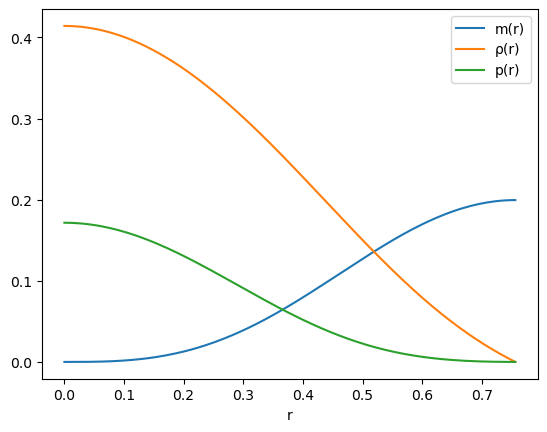

In [5]:
plt.plot(r[1:], m[1:], label='m(r)')
plt.plot(r[1:], ρ[1:], label='ρ(r)')
plt.plot(r[1:], p[1:], label='p(r)')
plt.xlabel('r')
# plt.yscale('log')
# plt.xscale('log')
plt.legend()

In [6]:
# Rescale alpha and psi to boundary conditions at the surface (Schwarzschild)
ψ_R =  1.0 + m[-1] / (2.0 * R[-1])
α_R = (1.0 - m[-1] / (2.0 * R[-1])) / ψ_R

In [7]:
# Check boundary conditions at the surface
assert np.allclose(ψ[-1], ψ_R)
assert np.allclose(α[-1], α_R)

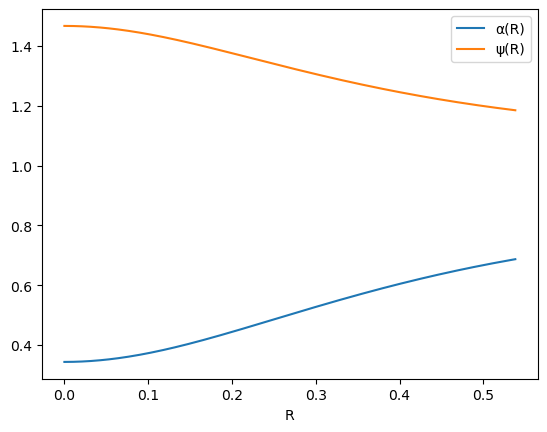

In [8]:
plt.plot(R, α, label='α(R)')
plt.plot(R, ψ, label='ψ(R)')
plt.xlabel('R')
plt.legend()

Check:
\begin{align*}
    \frac{\text{d} \Phi}{\text{d} r}
    \ = \
    \frac{1}{\alpha} \frac{\text{d} \alpha}{\text{d} r}
    \ = \
    \frac{m + 4\pi P r^{3}}{r\left(r - 2m\right)}
\end{align*}

np.float64(0.00010639234313658541)

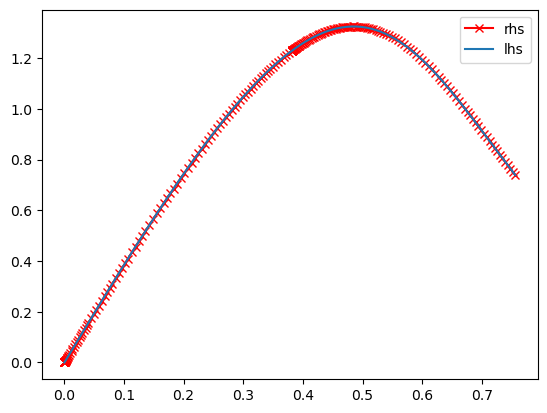

In [9]:
lhs = np.gradient(α, r, edge_order=2) / α
rhs = (m + 4.0 * np.pi * p * r**3) / (r * (r - 2.0 * m))

plt.plot(r, rhs, marker='x', c='red', label='rhs')
plt.plot(r, lhs,                      label='lhs')
plt.legend()

np.abs(lhs - rhs).max()

Check:
\begin{align*}
    \frac{\text{d} \log R}{\text{d} r} \ &= \ \frac{1}{\sqrt{r \left(r - 2 m(r)\right)}}
\end{align*}
or equivalently
\begin{align*}
    \frac{\text{d} R}{\text{d} r} \ &= \ \frac{R}{\sqrt{r \left(r - 2 m(r)\right)}}
\end{align*}

np.float64(3.9208750707064866e-05)

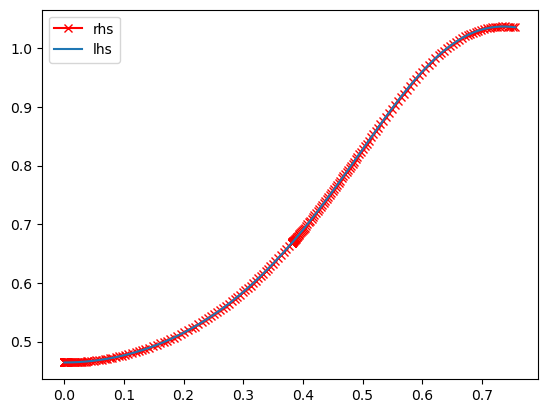

In [10]:
lhs = np.gradient(R, r, edge_order=2)
rhs = R / np.sqrt(r * (r - 2.0 * m))

plt.plot(r, rhs, marker='x', c='red', label='rhs')
plt.plot(r, lhs,                      label='lhs')
plt.legend()

np.abs(lhs - rhs).max()

Check:
\begin{align*}
    \frac{\text{d} m}{\text{d} r}    \ &= \ 4\pi r^{2} \rho
\end{align*}

np.float64(5.143143122036953e-05)

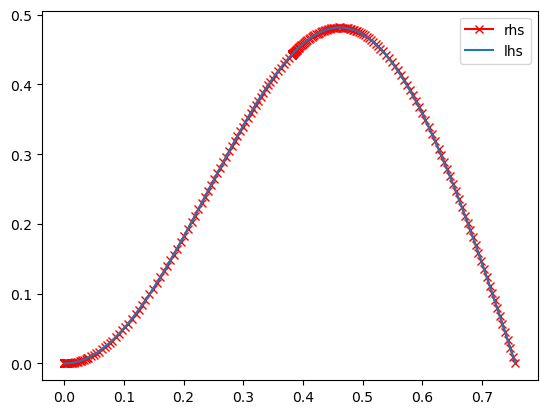

In [11]:
lhs = np.gradient(m, r, edge_order=2)
rhs = 4.0 * np.pi * r**2 * ρ

plt.plot(r, rhs, marker='x', c='red', label='rhs')
plt.plot(r, lhs,                      label='lhs')
plt.legend()

np.abs(lhs - rhs).max()

Check:
\begin{align*}
    \frac{\text{d} P}{\text{d} r}    \ &= -\frac{\left(\rho + P\right)\left(m + 4\pi P r^{3}\right)}{r\left(r - 2m\right)}
\end{align*}

np.float64(7.352638360585972e-05)

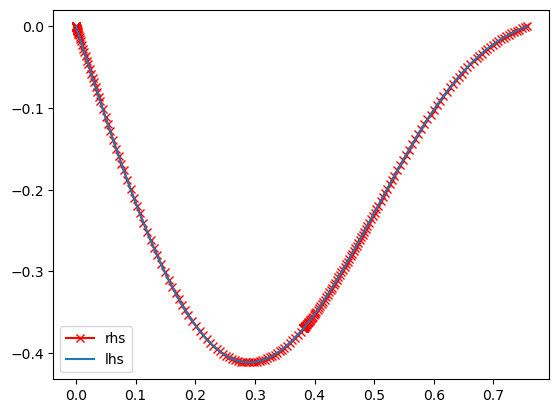

In [12]:
lhs = np.gradient(p, r, edge_order=2)
rhs = -(ρ + p) * (m + 4 * np.pi * r**3 * p) / (r * (r - 2 * m))

plt.plot(r, rhs, marker='x', c='red', label='rhs')
plt.plot(r, lhs,                      label='lhs')
plt.legend()

np.abs(lhs - rhs).max()

In [13]:
v_r = np.zeros_like(R)

ρh = ρ + p
W  = 1.0 / np.sqrt(1.0 - v_r**2)

E   = (ρh * W**2 - p               ) * ψ**6
S_r = (ρh * W**2 * v_r             ) * ψ**6
S   = (ρh * W**2 * v_r**2 + 3.0 * p) * ψ**6

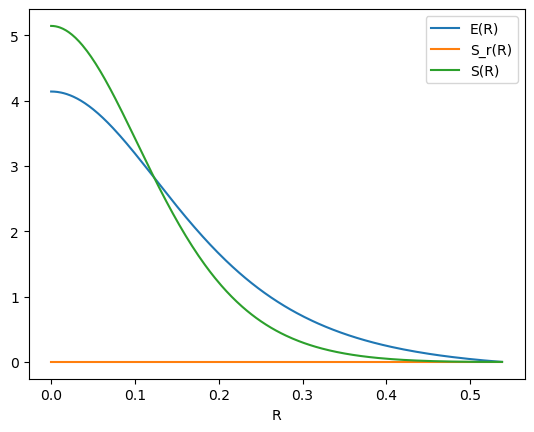

In [14]:
plt.plot(R, E,   label='E(R)')
plt.plot(R, S_r, label='S_r(R)')
plt.plot(R, S,   label='S(R)')
plt.xlabel('R')
plt.legend()

In [15]:
Nd = 100
Rs = np.linspace(1.0e-6*R[-1], R[-1], Nd)

E = interp1d(R, E)(Rs)
S = interp1d(R, S)(Rs)
α = interp1d(R, α)(Rs)
ψ = interp1d(R, ψ)(Rs)

In [16]:
np.save('tov.npy', np.stack((Rs, E, S, α, ψ)).T)